In [1]:
import numpy as np
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras_preprocessing import image
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.layers import Dense, Flatten, Dropout

In [2]:
# Load the VGG16 model without the top layer
# This allows us to use the convolutional base for feature extraction
conv_base = VGG16(
    weights='imagenet',
    include_top=False,  # Exclude the fully connected layers at the top
    input_shape=(150, 150, 3)
)

In [3]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [4]:
clf_model = Sequential(
    [
        conv_base,  # Add the convolutional base
        Flatten(),  # Flatten the output of the convolutional base
        Dense(256, activation='relu'),  # Fully connected layer with 256 units
        Dropout(0.5),  # Dropout layer to reduce overfitting
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ]
)
# Freeze the convolutional base to prevent its weights from being updated during training
conv_base.trainable = False

In [5]:
clf_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 2,097,665
Non-trainable params: 14,714,688
_________________________________________________________________


In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150),
)
test_ds = keras.utils.image_dataset_from_directory(
    directory='data/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150),
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [7]:
#  Preprocess the images by scaling pixel values to [0, 1] range
# and applying the VGG16 preprocessing function
def preprocess(image, label):
    image = tensorflow.cast(image/255., tensorflow.float32)
    return image, label


train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

In [8]:
clf_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Use binary crossentropy for binary classification
    metrics=['accuracy']
)

In [9]:
history = clf_model.fit(train_ds,
                        epochs=10, 
                        validation_data=test_ds,
                        verbose="auto", 
                        use_multiprocessing=True,
                        workers=100
                        )

Epoch 1/10
625/625 [==============================] - 108s 156ms/step - loss: 0.3131 - accuracy: 0.8670 - val_loss: 0.2219 - val_accuracy: 0.9024
Epoch 2/10
625/625 [==============================] - 93s 148ms/step - loss: 0.2320 - accuracy: 0.9021 - val_loss: 0.2134 - val_accuracy: 0.9064
Epoch 3/10
625/625 [==============================] - 93s 149ms/step - loss: 0.2065 - accuracy: 0.9136 - val_loss: 0.1983 - val_accuracy: 0.9120
Epoch 4/10
625/625 [==============================] - 132s 211ms/step - loss: 0.1905 - accuracy: 0.9213 - val_loss: 0.1987 - val_accuracy: 0.9146
Epoch 5/10
625/625 [==============================] - 108s 169ms/step - loss: 0.1842 - accuracy: 0.9227 - val_loss: 0.1987 - val_accuracy: 0.9130
Epoch 6/10
625/625 [==============================] - 96s 153ms/step - loss: 0.1753 - accuracy: 0.9288 - val_loss: 0.2027 - val_accuracy: 0.9162
Epoch 7/10
625/625 [==============================] - 95s 151ms/step - loss: 0.1559 - accuracy: 0.9354 - val_loss: 0.1979 - val

### We can see the accuracy is steadily increasing

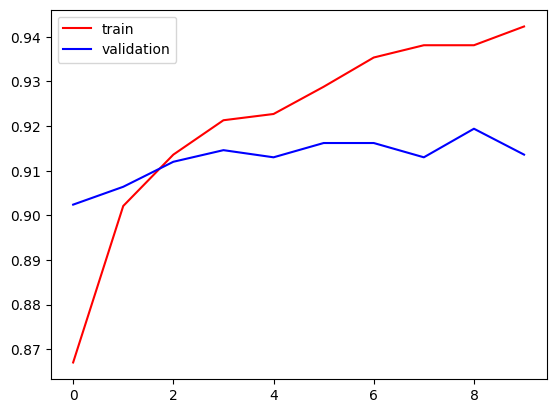

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

#### Loss is Decreasing

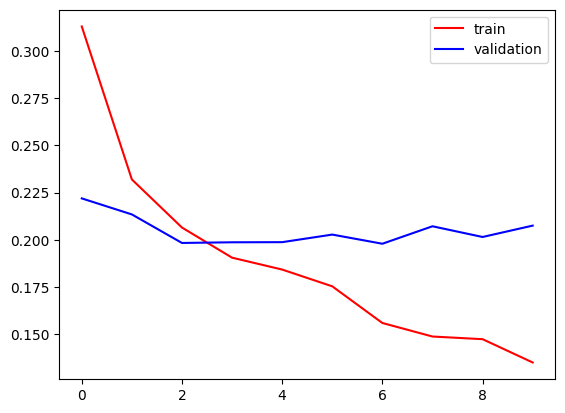

In [12]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()